# Image Classification using CNN and VGG16

In [ ]:
zip_file_path = "/content/FruitinAmazon.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Successfully extracted '/content/FruitinAmazon.zip' to '/content/'.


In [ ]:
import os

print(os.listdir("/content/FruitinAmazon"))

['train', 'test']


In [ ]:
train_dir = "/content/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/test"

# Import the required libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from PIL import Image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## Verify the dataset directory and extract class names

In [ ]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## Check for corrupted images

In [ ]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError, OSError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


## Count class balance

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


## Select one random image from each class

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

## Visualize randomly selected images

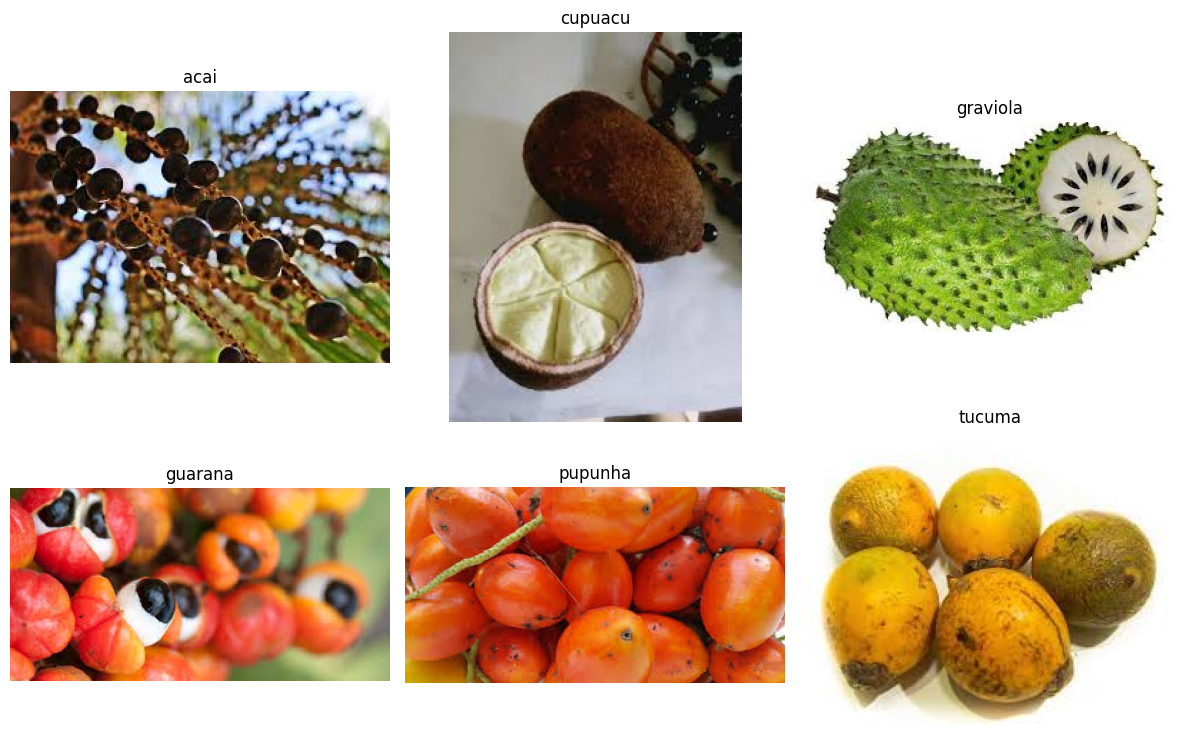

In [ ]:
num_classes = len(selected_images)
cols = 3
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

# Data Generation and Preprocessing

In [ ]:
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


## Display class names and number of classes

In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


## Check shape of one batch

In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


## Visualize images from training dataset

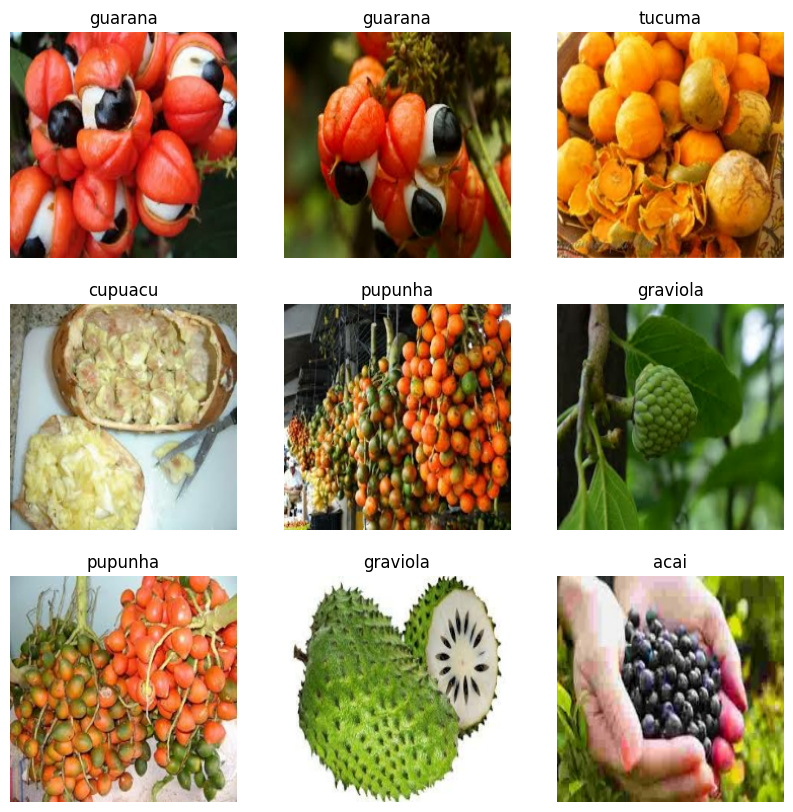

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# Data Augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

## Visualize augmented images

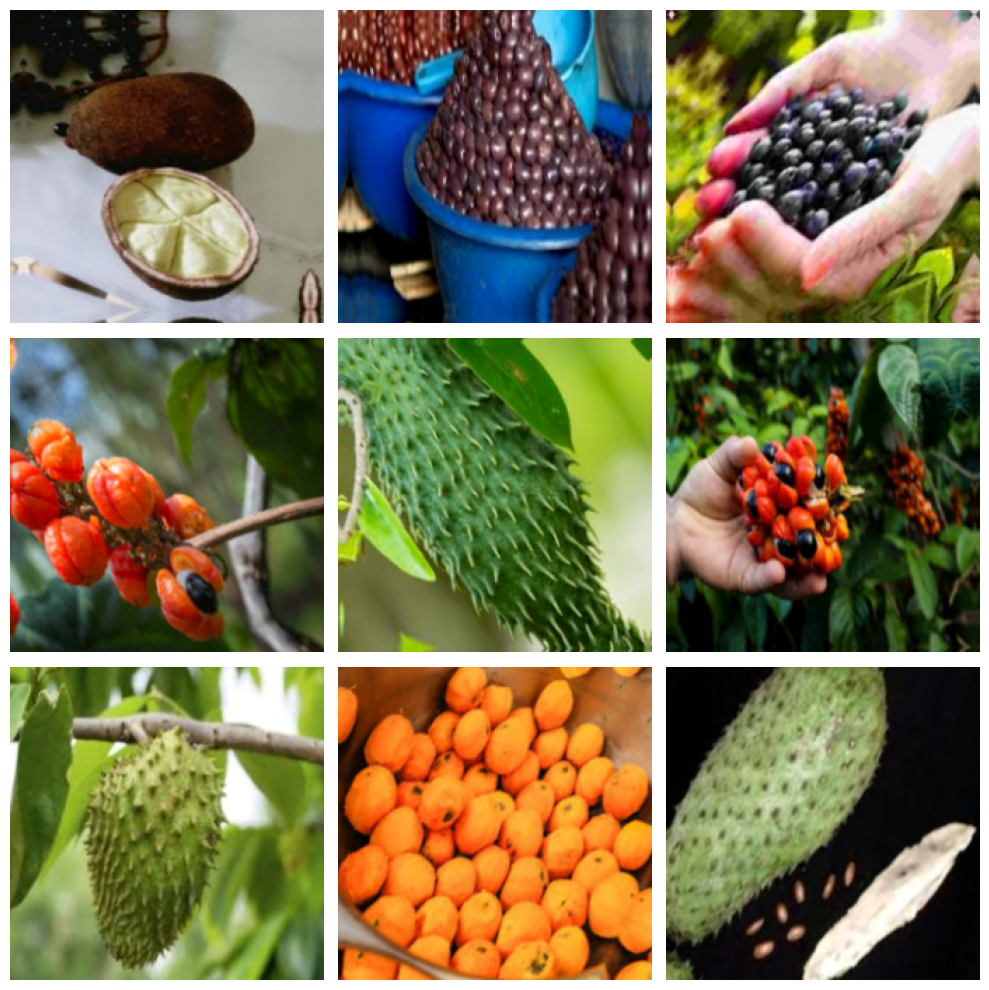

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

# Performance Optimization

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Model Building

In [ ]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Rescaling
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fully connected layers
    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

## Compile the CNN model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## View the model summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

## Train the CNN model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.0972 - loss: 2.3265 - val_accuracy: 0.2778 - val_loss: 1.7862
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.2639 - loss: 2.1834 - val_accuracy: 0.1667 - val_loss: 1.7986
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 10s/step - accuracy: 0.2083 - loss: 2.1500 - val_accuracy: 0.2778 - val_loss: 1.7827
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 9s/step - accuracy: 0.2222 - loss: 2.1250 - val_accuracy: 0.1667 - val_loss: 1.7713
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.1944 - loss: 2.2725 - val_accuracy: 0.1667 - val_loss: 1.7728
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - accuracy: 0.2222 - loss: 2.1372 - val_accuracy: 0.2222 - val_loss: 1.8320
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.2639 - loss: 1.9651 - val_accuracy: 0.1111 - val_loss: 1.8713
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.2639 - loss: 2.0265 - val_accuracy: 0.1111 - val_loss: 1.8910
Epoch 

## Plot training and validation accuracy/loss

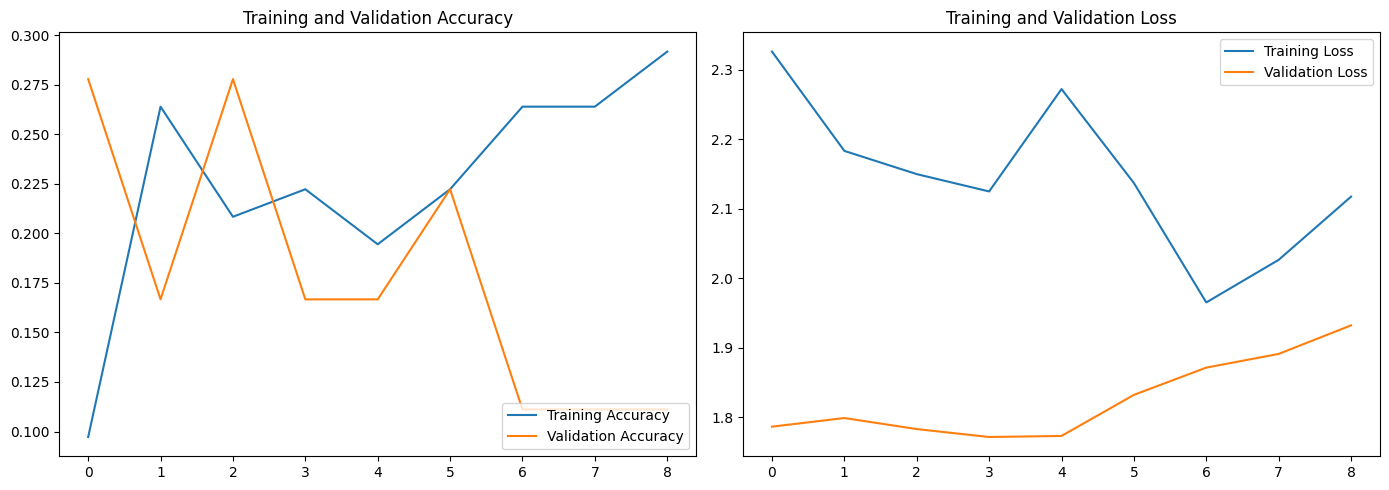

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# Evaluate the CNN model on test dataset

In [ ]:

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2667 - loss: 1.7773
Test Loss: 1.7773
Test Accuracy: 0.2667


In [ ]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_true[:10])

print("Classification Report for CNN Model:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted labels: [2 1 2 2 2 4 2 2 2 4]
Actual labels:    [0 0 0 0 0 1 1 1 1 1]
Classification Report for CNN Model:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.21      0.60      0.32         5
     guarana       0.67      0.40      0.50         5
     pupunha       0.33      0.60      0.43         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.27        30
   macro avg       0.20      0.27      0.21        30
weighted avg       0.20      0.27      0.21        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Plot confusion matrix

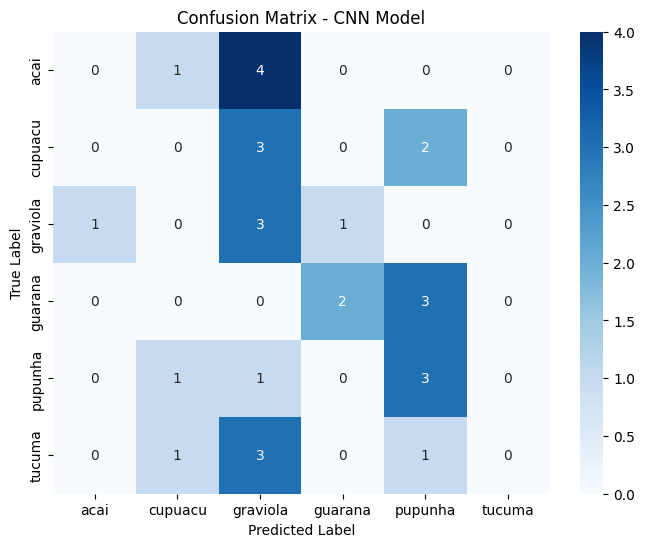

In [ ]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN Model")
plt.show()

# Save the trained CNN model

In [ ]:

model.save("cnn_fruits_model.keras")
print("CNN model saved successfully.")

CNN model saved successfully.


## Image Classification using Transfer Learning with VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds_tl = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size
)

val_ds_tl = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size
)

test_ds_tl = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


# Apply VGG16 preprocessing

In [ ]:

def preprocess_for_vgg(x, y):
    x = preprocess_input(tf.cast(x, tf.float32))
    return x, y

train_ds_tl = train_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)
test_ds_tl = test_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)

In [ ]:

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Load pre-trained VGG16 model without top layer

## Freeze all VGG16 layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False
# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

# Compile the transfer learning model

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Model Summary
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,422 (57.15 MB)

 Trainable params: 265,734 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
callbacks_tl = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_vgg16_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

history_tl = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=callbacks_tl
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 16s/step - accuracy: 0.2917 - loss: 7.2746 - val_accuracy: 0.3333 - val_loss: 3.7720
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 17s/step - accuracy: 0.4722 - loss: 4.1052 - val_accuracy: 0.6667 - val_loss: 1.3898
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.6944 - loss: 1.8248 - val_accuracy: 0.7778 - val_loss: 1.3677
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.8333 - loss: 1.0459 - val_accuracy: 0.7222 - val_loss: 1.3152
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.9444 - loss: 0.2164 - val_accuracy: 0.8333 - val_loss: 1.0110
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 54s 18s/step - accuracy: 0.8889 - loss: 0.3774 - val_accuracy: 0.8889 - val_loss: 1.0416
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.9306 - loss: 0.3499 - val_accuracy: 0.8889 - val_loss: 1.0917
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.9583 - loss: 0.2006 - val_accuracy: 0.8889 - val_loss: 1.1468


# Plot training and validation accuracy/loss for VGG16

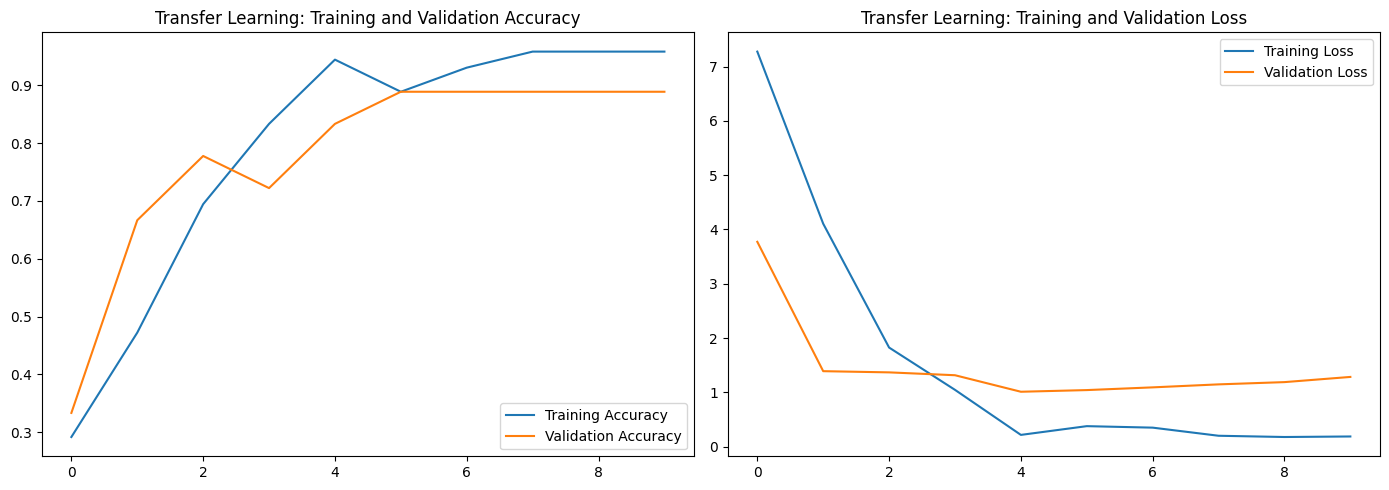

In [ ]:
acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']
loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range_tl = range(len(acc_tl))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_tl, acc_tl, label='Training Accuracy')
plt.plot(epochs_range_tl, val_acc_tl, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Transfer Learning: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_tl, loss_tl, label='Training Loss')
plt.plot(epochs_range_tl, val_loss_tl, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Transfer Learning: Training and Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the VGG16 model
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds_tl)
print(f"Transfer Learning Test Loss: {test_loss_tl:.4f}")
print(f"Transfer Learning Test Accuracy: {test_acc_tl:.4f}")

# Generate inference output
y_true_tl = np.concatenate([labels.numpy() for _, labels in test_ds_tl])
y_pred_probs_tl = transfer_model.predict(test_ds_tl)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

print("Predicted class labels:", y_pred_tl[:10])
print("Actual class labels:   ", y_true_tl[:10])

# Generate classification report for VGG16
print("Classification Report for Transfer Learning Model:\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 0.9000 - loss: 0.5153
Transfer Learning Test Loss: 0.5153
Transfer Learning Test Accuracy: 0.9000
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
Predicted class labels: [0 0 0 0 0 1 5 1 1 1]
Actual class labels:    [0 0 0 0 0 1 1 1 1 1]
Classification Report for Transfer Learning Model:

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.67      0.80      0.73         5

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



## Plot confusion matrix for VGG16

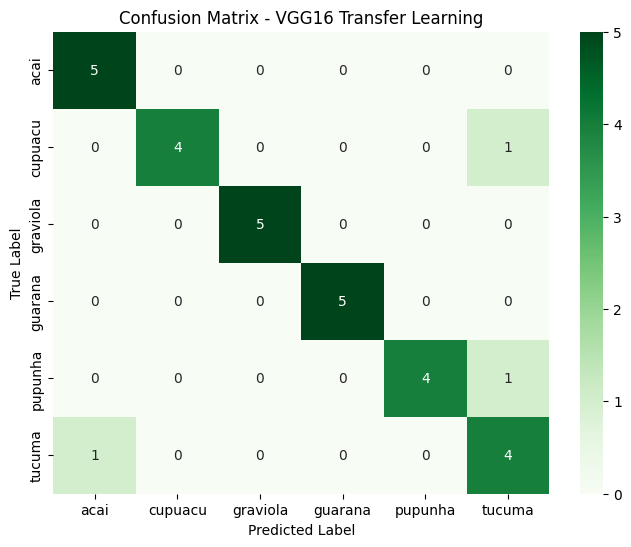

Transfer learning model saved successfully.


In [ ]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG16 Transfer Learning")
plt.show()

transfer_model.save("vgg16_fruits_model.keras")
print("Transfer learning model saved successfully.")

In [ ]:
# Compare CNN from scratch vs Transfer Learning
print("Model Comparison:")
print(f"CNN from Scratch Test Accuracy      : {test_acc:.4f}")
print(f"Transfer Learning Test Accuracy     : {test_acc_tl:.4f}")

if test_acc_tl > test_acc:
    print("Transfer learning improved the performance compared to training from scratch.")
elif test_acc_tl < test_acc:
    print("Training from scratch performed better than transfer learning in this case.")
else:
    print("Both models achieved similar performance.")

Model Comparison:
CNN from Scratch Test Accuracy      : 0.2667
Transfer Learning Test Accuracy     : 0.9000
Transfer learning improved the performance compared to training from scratch.
